# Processing Puromycin Data

____

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

notebook_dir = Path.cwd().resolve()
if not (notebook_dir / 'inhibitors.py').exists():
    notebook_dir = notebook_dir / 'notebooks' / 'Figure_6_RNA_stability_puromycin'
if not (notebook_dir / 'inhibitors.py').exists():
    raise FileNotFoundError(
        'Run this notebook from the repository root or '
        'notebooks/Figure_6_RNA_stability_puromycin.'
    )
sys.path.insert(0, str(notebook_dir))
from microlive.imports import *
from microlive import microscopy as mi
import inhibitors as INH

## Data Configuration
___

In [2]:
# Loading data
data_dir = Path(r'/Volumes/Luis_DRIVE/UTag_puro_20260701/results')
plasmid_mapping = {'pNZ335': 'UTag', 'pNZ377': 'UTag_DC'}
folders = [f.name for f in data_dir.iterdir() if f.is_dir()]
list_folder_substrings = [p for p in plasmid_mapping if any(p in f for f in folders)]
list_names = [plasmid_mapping[p] for p in list_folder_substrings]
print(list_folder_substrings) 
print(list_names)             


['pNZ335', 'pNZ377']
['UTag', 'UTag_DC']


## Processing & Plotting Configuration
___

In [3]:
# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
frame_interval_sec = 20
use_sem = True
show_summary = False
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None
normalization_method = None  # options: 'mean', 'minmax', 'percentile', None
percentile_range = None      # only used with normalization_method='percentile'
treatment_label = 'Puromycin'

# ── What to Report ────────────────────────────────────────
report_spots = True  # True = number of spots; False = intensity

# ── Plotting Parameters ───────────────────────────────────
figsize = (4.5*1.5, 3*1.5)
font_family = 'Arial'
axis_label_size = 20
tick_label_size = 18
legend_font_size = 16
marker_size = 8
data_line_width = 2.5
error_bar_line_width = 2.0
error_bar_cap_thickness = 1.5
fit_line_width = 2.5
capsize = 5
ylims = (-26, 800) if not report_spots else (-0.02, 1.1)
xlims = (-1.5, 10)
show_runoff_time = False
show_treatment_line = False
threshold_percentage_for_runoff = 0.1
figures_folder = notebook_dir / 'figures'
raw_data_folder = notebook_dir / 'raw_data'
figures_folder.mkdir(parents=True, exist_ok=True)
raw_data_folder.mkdir(parents=True, exist_ok=True)


## Plasmid Substrings
___

In [4]:
substring_1 = 'pNZ335'
substring_2 = 'pNZ377'


## Processing & Plotting
___

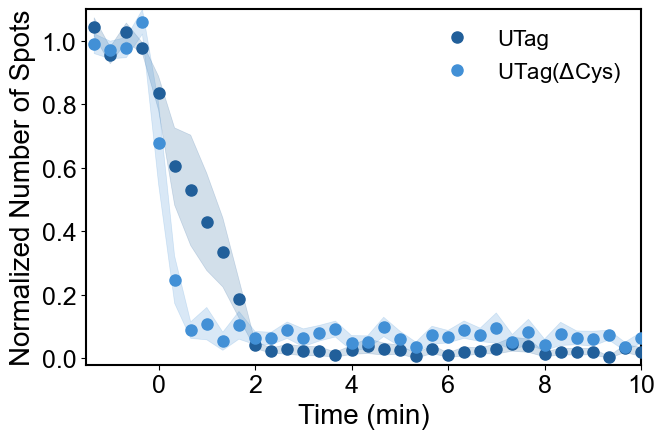

In [5]:
selected_field = 'spot_int_ch_0'

# ── Process both plasmids ────────────────────────────
process_kwargs = dict(
    data_dir=data_dir,
    inhibitor_frame_index=inhibitor_frame_index,
    selected_field=selected_field,
    use_sem=use_sem,
    show_summary=show_summary,
    max_percentage_threshold_after_treatment=max_percentage_threshold_after_treatment,
    frame_interval_sec=frame_interval_sec,
    normalization_method=normalization_method,
    percentile_range=percentile_range,
)

responding_indices_1, frames_1, intensities_1, spots_per_frame_1, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_1, **process_kwargs,
)
responding_indices_2, frames_2, intensities_2, spots_per_frame_2, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_2, **process_kwargs,
)


# ── Select data to plot ───────────────────────────────────
if report_spots:
    data_1, data_2 = spots_per_frame_1, spots_per_frame_2
    y_label = 'Normalized Number of Spots'
else:
    data_1, data_2 = intensities_1, intensities_2
    y_label = 'Norm. Intensity' if normalization_method else 'Intensity'

# ── Plot ──────────────────────────────────────────────────
puromycin_plot_records = []
INH.plot_multiple_inhibitors(
    full_frames_list=[frames_1, frames_2],
    intensities_normalized_list=[data_1, data_2],
    inhibitor_frame_index=inhibitor_frame_index,
    legend_labels=['UTag', r'UTag($\Delta$Cys)'],
    legend_position='upper right',
    colors=['#215F9A', '#4290D6'],
    figsize=figsize,
    font_family=font_family,
    axis_label_size=axis_label_size,
    tick_label_size=tick_label_size,
    legend_font_size=legend_font_size,
    marker_size=marker_size,
    data_line_width=data_line_width,
    error_bar_line_width=error_bar_line_width,
    error_bar_cap_thickness=error_bar_cap_thickness,
    fit_line_width=fit_line_width,
    capsize=capsize,
    plot_name='Figure_6G_puromycin_spot_runoff',
    filename_prefix='',
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    show_runoff_time=show_runoff_time,
    ylims=ylims,
    xlims=xlims,
    show_treatment_line=show_treatment_line,
    y_label=y_label,
    treatment_label=treatment_label,
    source_data_collector=puromycin_plot_records,
    results_folder=figures_folder,
)

canonical_puromycin_labels = ['UTag', 'UTag_DeltaCys']
puromycin_source_rows = []
for condition, record in zip(canonical_puromycin_labels, puromycin_plot_records):
    visible_mask = (record['time'] >= xlims[0]) & (record['time'] <= xlims[1])
    for time_min, mean_value, sem_value in zip(
            record['time'][visible_mask],
            record['mean'][visible_mask],
            record['error'][visible_mask]):
        puromycin_source_rows.append({
            'condition': condition,
            'time_min': time_min,
            'mean_normalized_spot_count': mean_value,
            'sem_normalized_spot_count': sem_value,
            'n_cells': record['n_cells_total'],
        })

puromycin_source_data_df = pd.DataFrame(puromycin_source_rows)
expected_puromycin_counts = {'UTag': 35, 'UTag_DeltaCys': 35}
observed_puromycin_counts = puromycin_source_data_df['condition'].value_counts().to_dict()
if observed_puromycin_counts != expected_puromycin_counts:
    raise ValueError(
        f'Unexpected Figure 6G source-data counts: {observed_puromycin_counts}'
    )
if puromycin_source_data_df.groupby('condition')['n_cells'].first().to_dict() != {
        'UTag': 8, 'UTag_DeltaCys': 7}:
    raise ValueError('Unexpected Figure 6G cell counts.')
puromycin_source_data_df.to_csv(
    raw_data_folder / 'Figure_6G_puromycin_spot_runoff_curves.csv',
    index=False,
)

In [6]:
print(f"UTag:    {len(responding_indices_1)} responding / {intensities_1.shape[0]} total cells")
print(f"UTag_DC: {len(responding_indices_2)} responding / {intensities_2.shape[0]} total cells")

UTag:    8 responding / 8 total cells
UTag_DC: 7 responding / 7 total cells
